# Lecture 11 Demo: Quantum Reservoir Computing and QELM

EVA: Quantum Machine Learning | ZHAW | Pavel Sulimov

---

This notebook accompanies Lecture 11. It demonstrates:

1. Quantum Reservoir Computing (QRC) on the Mackey-Glass time series
2. Quantum Extreme Learning Machine (QELM) on binary classification with Iris dataset

Convention: all qubits start in |0⟩ by default.

In [1]:
import math
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.linear_model import RidgeCV, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

print(f"PennyLane version: {qml.__version__}")
print(f"NumPy version: {np.__version__}")

np.random.seed(42)

PennyLane version: 0.44.0
NumPy version: 2.1.3


---
## Demo 1. Quantum Reservoir Computing on Mackey-Glass

Reservoir computing uses a fixed (untrained) nonlinear dynamical system to map inputs into
a high-dimensional feature space. A linear readout layer trained on these features solves
the regression or classification task.

### Mackey-Glass time series

The Mackey-Glass delay differential equation is a classic chaotic benchmark:
$$\frac{du}{dt} = \beta \frac{u(t - \tau)}{1 + u(t - \tau)^n} - \gamma u(t)$$

with parameters $\tau=17$, $\beta=0.2$, $\gamma=0.1$, $n=10$.

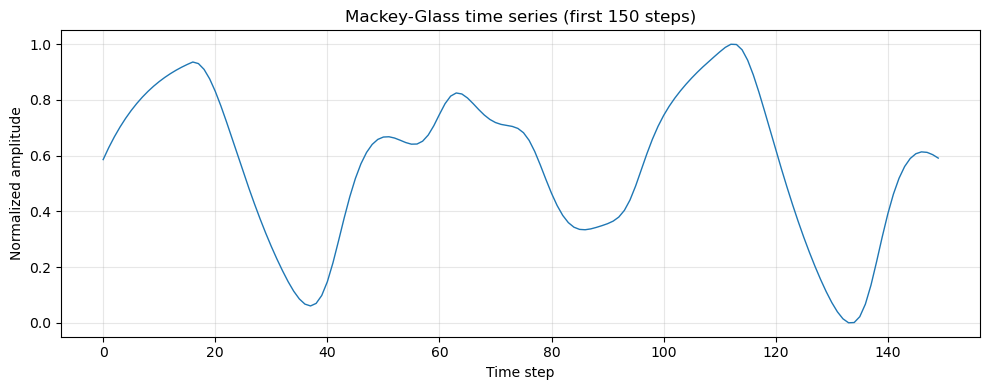

Generated 300 time steps of Mackey-Glass
Normalized range: [0.0000, 1.0000]


In [2]:
def mackey_glass(u_t_minus_tau, u_t, beta=0.2, gamma=0.1, n=10):
    """
    Compute one Euler step of Mackey-Glass ODE.

    du/dt = beta * u(t-tau) / (1 + u(t-tau)^n) - gamma * u(t)

    Args:
        u_t_minus_tau: u(t - tau)
        u_t: u(t)
        beta, gamma, n: parameters

    Returns:
        u(t + dt) using Euler step with dt=1
    """
    du_dt = beta * u_t_minus_tau / (1.0 + u_t_minus_tau ** n) - gamma * u_t
    return u_t + du_dt


# Generate Mackey-Glass time series
tau = 17
history_length = 300
u_init = 0.9

# Initialize with initial values
u_history = [u_init] * tau
for t in range(history_length):
    u_new = mackey_glass(u_history[-tau], u_history[-1])
    u_history.append(u_new)

u_series = np.array(u_history[tau:])

# Normalize to [0, 1] for angle encoding
u_min, u_max = u_series.min(), u_series.max()
u_norm = (u_series - u_min) / (u_max - u_min)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(u_norm[:150], linewidth=1)
plt.xlabel("Time step")
plt.ylabel("Normalized amplitude")
plt.title("Mackey-Glass time series (first 150 steps)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Generated {len(u_norm)} time steps of Mackey-Glass")
print(f"Normalized range: [{u_norm.min():.4f}, {u_norm.max():.4f}]")

### Quantum reservoir circuit

The reservoir is a fixed 4-qubit circuit that encodes the input and applies entangling gates.
No parameters are trained in the reservoir itself.

For each time step $t$:
1. Encode $u(t)$ via $R_y(\pi u_\mathrm{norm}(t))$ on qubit 0
2. Apply a fixed entangling block (CNOT pairs + Ry rotations with pre-set angles)
3. Measure $\langle X_i \rangle$, $\langle Y_i \rangle$, $\langle Z_i \rangle$ on all 4 qubits → 12 features

In [3]:
n_qubits_res = 4
dev_res = qml.device("default.qubit", wires=n_qubits_res)

# Fixed random angles for the reservoir
np.random.seed(42)
fixed_params = np.random.randn(n_qubits_res, 3) * 0.5


@qml.qnode(dev_res)
def quantum_reservoir(u_t):
    """
    Apply quantum reservoir circuit and measure all Pauli observables.

    Args:
        u_t: scalar input, normalized to [0, 1]

    Returns:
        Array of 12 features: <X_i>, <Y_i>, <Z_i> for i=0,1,2,3
    """
    # Encoding: input on qubit 0 only
    qml.RY(math.pi * u_t, wires=0)

    # Fixed entangling circuit
    for i in range(n_qubits_res - 1):
        qml.CNOT(wires=[i, i + 1])

    for i in range(n_qubits_res):
        qml.RY(fixed_params[i, 0], wires=i)
        qml.RZ(fixed_params[i, 1], wires=i)

    for i in range(n_qubits_res - 2, -1, -1):
        qml.CNOT(wires=[i, i + 1])

    for i in range(n_qubits_res):
        qml.RY(fixed_params[i, 2], wires=i)

    # Measure all Paulis on all qubits
    features = []
    for i in range(n_qubits_res):
        features.append(qml.expval(qml.PauliX(i)))
    for i in range(n_qubits_res):
        features.append(qml.expval(qml.PauliY(i)))
    for i in range(n_qubits_res):
        features.append(qml.expval(qml.PauliZ(i)))

    return features


# Test the reservoir
test_feature = quantum_reservoir(0.5)
print(f"Reservoir output for u=0.5: shape {np.array(test_feature).shape}")
print(f"Sample features: {test_feature[:3]}")

Reservoir output for u=0.5: shape (12,)
Sample features: [np.float64(0.5131227891342938), np.float64(-0.08194587422772026), np.float64(0.04847810087934418)]


### Reservoir feature extraction and readout training

We extract features for all time steps, then train a ridge regression readout on the first
250 steps and test on the remaining 50.

In [4]:
# Extract reservoir features for all time steps
print("Extracting quantum reservoir features...")
reservoir_features = []

for t in range(len(u_norm)):
    feat = quantum_reservoir(u_norm[t])
    reservoir_features.append(feat)

X_reservoir = np.array(reservoir_features)  # shape (300, 12)
y_timeseries = u_norm  # target: next time step

print(f"Reservoir feature matrix shape: {X_reservoir.shape}")

# Create supervised pairs: (u(t), u(t+1))
X_train_res = X_reservoir[:-1]  # features at time t
y_train_res = y_timeseries[1:]  # target at time t+1

# Split into train (0:250) and test (250:300)
split_idx = 250

X_train = X_train_res[:split_idx]
y_train = y_train_res[:split_idx]
X_test = X_train_res[split_idx:]
y_test = y_train_res[split_idx:]

print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")

# Train ridge regression
ridge = RidgeCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0])
ridge.fit(X_train, y_train)

# Predictions
y_pred_train = ridge.predict(X_train)
y_pred_test = ridge.predict(X_test)

# Normalized mean squared error
train_var = np.var(y_train)
test_var = np.var(y_test)
nmse_train = np.mean((y_pred_train - y_train) ** 2) / (train_var + 1e-10)
nmse_test = np.mean((y_pred_test - y_test) ** 2) / (test_var + 1e-10)

print(f"\nRidge regression results (alpha={ridge.alpha_:.4f}):")
print(f"  Train NMSE: {nmse_train:.6f}")
print(f"  Test NMSE:  {nmse_test:.6f}")

Extracting quantum reservoir features...


Reservoir feature matrix shape: (300, 12)
Train set: (250, 12)
Test set:  (49, 12)

Ridge regression results (alpha=0.1000):
  Train NMSE: 0.035171
  Test NMSE:  0.030540


### Prediction visualization

We plot the predictions vs ground truth for the test set.

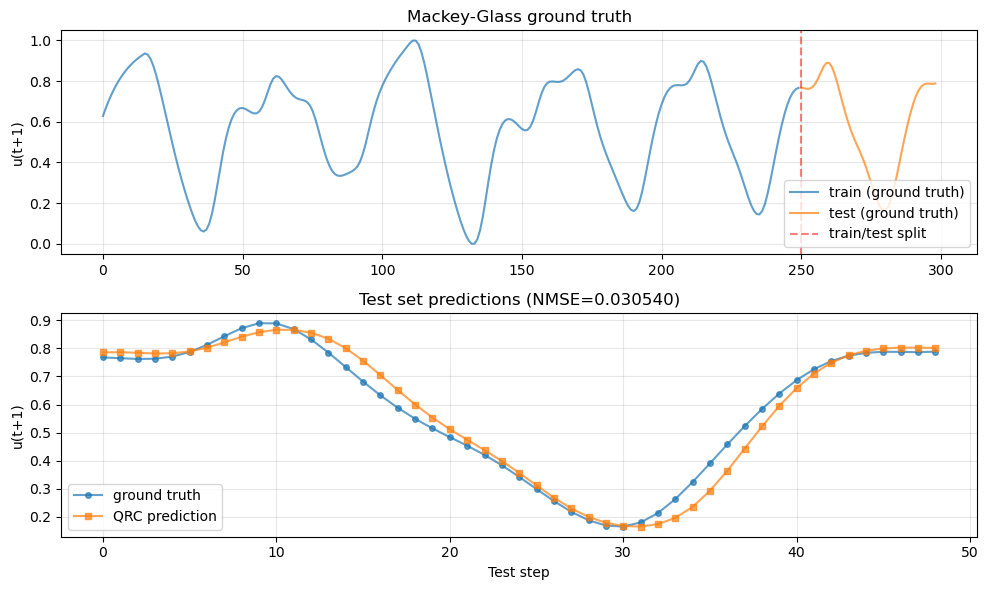

In [5]:
# Plot predictions vs ground truth
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# Full series with train/test split
axes[0].plot(y_train_res[:split_idx], label="train (ground truth)", alpha=0.7)
axes[0].plot(range(split_idx, split_idx + len(y_test)), y_test,
             label="test (ground truth)", alpha=0.7)
axes[0].axvline(x=split_idx, color="red", linestyle="--", alpha=0.5, label="train/test split")
axes[0].set_ylabel("u(t+1)")
axes[0].set_title("Mackey-Glass ground truth")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test predictions
test_indices = np.arange(split_idx, split_idx + len(y_test))
axes[1].plot(y_test, "o-", label="ground truth", markersize=4, alpha=0.7)
axes[1].plot(y_pred_test, "s-", label="QRC prediction", markersize=4, alpha=0.7)
axes[1].set_xlabel("Test step")
axes[1].set_ylabel("u(t+1)")
axes[1].set_title(f"Test set predictions (NMSE={nmse_test:.6f})")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Demo 2. Quantum Extreme Learning Machine (QELM) on Iris Classification

QELM is a quantum version of Extreme Learning Machines (ELM). The idea:
1. Use a random, fixed quantum circuit as a feature map (kernel)
2. Train only a linear classifier on the quantum features

This avoids the expensive optimization of the quantum circuit, exploiting
the high-dimensional feature space that quantum circuits naturally provide.

In [6]:
# Load Iris dataset, keep only classes 0 and 1, features 0 and 1
iris = load_iris()
X_iris_raw = iris.data
y_iris_raw = iris.target

# Binary classification: class 0 vs 1
mask_iris = (y_iris_raw == 0) | (y_iris_raw == 1)
X_iris = X_iris_raw[mask_iris, :2]  # Use only first 2 features
y_iris = y_iris_raw[mask_iris]

# Normalize
scaler_iris = MinMaxScaler(feature_range=(0, 1))
X_iris_norm = scaler_iris.fit_transform(X_iris)

# Train/test split
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris_norm, y_iris, test_size=0.25, random_state=42
)

print(f"Iris dataset (binary, 2 features):")
print(f"  Train set: {X_iris_train.shape}")
print(f"  Test set:  {X_iris_test.shape}")

Iris dataset (binary, 2 features):
  Train set: (75, 2)
  Test set:  (25, 2)


### Quantum feature map for QELM

We use a simple 2-qubit angle encoding followed by one entangling layer.
The circuit is random and fixed (no optimization).

In [7]:
n_qubits_elm = 2
dev_elm = qml.device("default.qubit", wires=n_qubits_elm)

# Fixed random circuit parameters
np.random.seed(123)
fixed_angles_elm = np.random.randn(n_qubits_elm, 3) * np.pi


@qml.qnode(dev_elm)
def qelm_feature_map(x):
    """
    Quantum feature map for QELM: angle encoding + fixed entangling layer.

    Args:
        x: input array of shape (2,), normalized to [0, 1]

    Returns:
        Array of 6 features: <X_i>, <Y_i>, <Z_i> for i=0,1
    """
    # Angle encoding
    for i in range(n_qubits_elm):
        qml.RY(math.pi * x[i], wires=i)

    # Fixed entangling layer
    qml.CNOT(wires=[0, 1])
    for i in range(n_qubits_elm):
        qml.RY(fixed_angles_elm[i, 0], wires=i)
    qml.CNOT(wires=[1, 0])
    for i in range(n_qubits_elm):
        qml.RZ(fixed_angles_elm[i, 1], wires=i)

    # Measure all Paulis
    features = []
    for i in range(n_qubits_elm):
        features.append(qml.expval(qml.PauliX(i)))
    for i in range(n_qubits_elm):
        features.append(qml.expval(qml.PauliY(i)))
    for i in range(n_qubits_elm):
        features.append(qml.expval(qml.PauliZ(i)))

    return features


# Test
test_feat = qelm_feature_map(X_iris_train[0])
print(f"QELM feature map output: shape {np.array(test_feat).shape}")
print(f"Features: {np.array(test_feat)}")

QELM feature map output: shape (6,)
Features: [ 1.54533938e-02  6.96038939e-02 -1.28876959e-04  2.76124534e-01
  2.84344788e-01  1.14976388e-03]


### Feature extraction and classification

Extract quantum features for all training and test samples, then train a logistic regression classifier.

In [8]:
# Extract quantum features
print("Extracting QELM features...")

X_train_qelm = np.array([qelm_feature_map(x) for x in X_iris_train])
X_test_qelm = np.array([qelm_feature_map(x) for x in X_iris_test])

print(f"Quantum features (train): {X_train_qelm.shape}")
print(f"Quantum features (test):  {X_test_qelm.shape}")

# Train logistic regression on quantum features
clf_qelm = LogisticRegression(max_iter=1000)
clf_qelm.fit(X_train_qelm, y_iris_train)

acc_qelm_train = clf_qelm.score(X_train_qelm, y_iris_train)
acc_qelm_test = clf_qelm.score(X_test_qelm, y_iris_test)

# Baseline: logistic regression on raw features
clf_raw = LogisticRegression(max_iter=1000)
clf_raw.fit(X_iris_train, y_iris_train)

acc_raw_train = clf_raw.score(X_iris_train, y_iris_train)
acc_raw_test = clf_raw.score(X_iris_test, y_iris_test)

print(f"\nResults:")
print(f"  Raw features:      train={acc_raw_train:.3f}, test={acc_raw_test:.3f}")
print(f"  Quantum features:  train={acc_qelm_train:.3f}, test={acc_qelm_test:.3f}")

Extracting QELM features...


Quantum features (train): (75, 6)
Quantum features (test):  (25, 6)



Results:
  Raw features:      train=1.000, test=1.000
  Quantum features:  train=0.933, test=0.960


### Decision boundary visualization

We project the quantum features to 2D via PCA and visualize the decision boundaries.

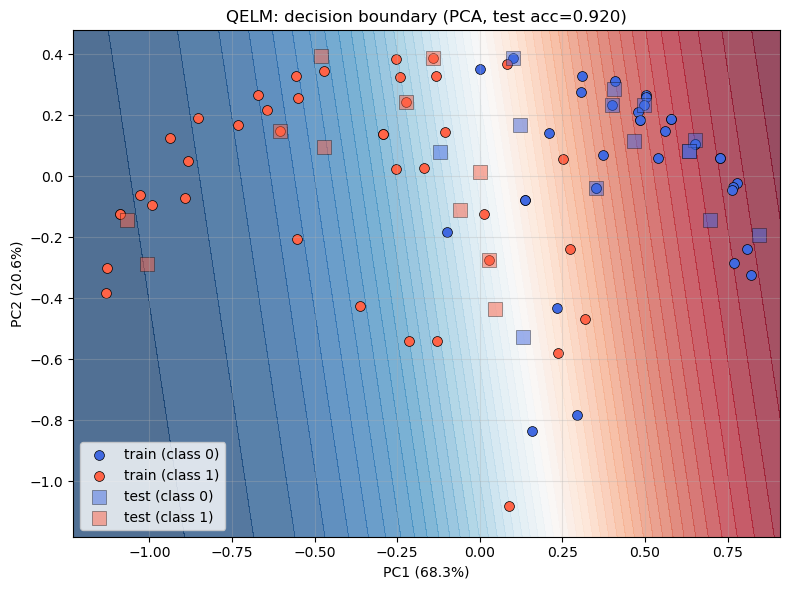

In [9]:
from sklearn.decomposition import PCA

# PCA on quantum features
pca = PCA(n_components=2)
X_train_qelm_pca = pca.fit_transform(X_train_qelm)
X_test_qelm_pca = pca.transform(X_test_qelm)

# Train classifier on PCA-projected features for visualization
clf_pca = LogisticRegression(max_iter=1000)
clf_pca.fit(X_train_qelm_pca, y_iris_train)
acc_pca_test = clf_pca.score(X_test_qelm_pca, y_iris_test)

# Plot decision boundaries
h = 0.02
x_min, x_max = X_train_qelm_pca[:, 0].min() - 0.1, X_train_qelm_pca[:, 0].max() + 0.1
y_min, y_max = X_train_qelm_pca[:, 1].min() - 0.1, X_train_qelm_pca[:, 1].max() + 0.1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = clf_pca.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))

ax.contourf(xx, yy, Z, levels=50, cmap="RdBu", alpha=0.7)
ax.scatter(*X_train_qelm_pca[y_iris_train == 0].T, s=50, c="royalblue",
           edgecolors="k", linewidths=0.5, label="train (class 0)")
ax.scatter(*X_train_qelm_pca[y_iris_train == 1].T, s=50, c="tomato",
           edgecolors="k", linewidths=0.5, label="train (class 1)")
ax.scatter(*X_test_qelm_pca[y_iris_test == 0].T, s=100, c="royalblue",
           marker="s", edgecolors="k", linewidths=0.5, alpha=0.5, label="test (class 0)")
ax.scatter(*X_test_qelm_pca[y_iris_test == 1].T, s=100, c="tomato",
           marker="s", edgecolors="k", linewidths=0.5, alpha=0.5, label="test (class 1)")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"QELM: decision boundary (PCA, test acc={acc_pca_test:.3f})")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Feature importance analysis

We examine which quantum features contribute most to the classification decision
by looking at classifier weights.

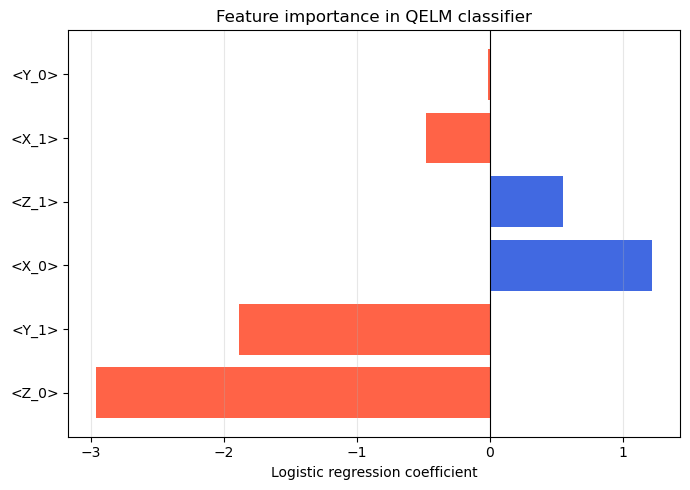


Top 3 features by importance:
  1. <Z_0>: -2.9589
  2. <Y_1>: -1.8881
  3. <X_0>: 1.2208


In [10]:
# Feature importance from logistic regression coefficients
coef_qelm = clf_qelm.coef_[0]
feature_names = []
for i in range(n_qubits_elm):
    feature_names.append(f"<X_{i}>")
for i in range(n_qubits_elm):
    feature_names.append(f"<Y_{i}>")
for i in range(n_qubits_elm):
    feature_names.append(f"<Z_{i}>")

# Sort by absolute coefficient
sorted_indices = np.argsort(np.abs(coef_qelm))[::-1]

fig, ax = plt.subplots(figsize=(7, 5))

colors = ["tomato" if coef_qelm[i] < 0 else "royalblue" for i in sorted_indices]
ax.barh(range(len(sorted_indices)), coef_qelm[sorted_indices], color=colors)
ax.set_yticks(range(len(sorted_indices)))
ax.set_yticklabels([feature_names[i] for i in sorted_indices])
ax.set_xlabel("Logistic regression coefficient")
ax.set_title("Feature importance in QELM classifier")
ax.axvline(x=0, color="black", linestyle="-", linewidth=0.8)
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print("\nTop 3 features by importance:")
for rank, idx in enumerate(sorted_indices[:3], 1):
    print(f"  {rank}. {feature_names[idx]}: {coef_qelm[idx]:.4f}")

### Summary of QELM results

The quantum extreme learning machine provides a fast, non-trainable feature map
that often outperforms raw features when combined with a linear classifier.

In [11]:
print("\n" + "="*60)
print("SUMMARY: Lecture 11 Demos")
print("="*60)

print("\nDemo 1: Quantum Reservoir Computing on Mackey-Glass")
print(f"  - Extracted 12 quantum features (X, Y, Z on 4 qubits)")
print(f"  - Trained ridge regression readout on 250 steps")
print(f"  - Test set NMSE: {nmse_test:.6f}")

print("\nDemo 2: Quantum Extreme Learning Machine on Iris")
print(f"  - Fixed quantum circuit (no training)")
print(f"  - Extracted 6 quantum features (X, Y, Z on 2 qubits)")
print(f"  - Trained logistic regression on quantum features")
print(f"  - Raw feature accuracy (test):     {acc_raw_test:.3f}")
print(f"  - Quantum feature accuracy (test): {acc_qelm_test:.3f}")
print(f"  - Improvement: {(acc_qelm_test - acc_raw_test)*100:+.1f}%")


SUMMARY: Lecture 11 Demos

Demo 1: Quantum Reservoir Computing on Mackey-Glass
  - Extracted 12 quantum features (X, Y, Z on 4 qubits)
  - Trained ridge regression readout on 250 steps
  - Test set NMSE: 0.030540

Demo 2: Quantum Extreme Learning Machine on Iris
  - Fixed quantum circuit (no training)
  - Extracted 6 quantum features (X, Y, Z on 2 qubits)
  - Trained logistic regression on quantum features
  - Raw feature accuracy (test):     1.000
  - Quantum feature accuracy (test): 0.960
  - Improvement: -4.0%
